In [1]:
import os
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.datasets as dsets

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.11.0
CUDA available: False


In [4]:
RAW_DIR       = "./data/raw"        # Where raw GTSRB data is downloaded
PROCESSED_DIR = "./data/processed"  # Where cleaned images are saved
IMG_SIZE      = 64                  # Output resolution (64 or 128 recommended)
MAX_PER_CLASS = 200                 # Max images sampled per sign class
BATCH_SIZE    = 64                  # DataLoader batch size
SEED          = 42                  # Reproducibility

random.seed(SEED)
torch.manual_seed(SEED)
print("Config set.")

Config set.


In [6]:
Path(RAW_DIR).mkdir(parents=True, exist_ok=True)

print("Downloading GTSRB training set...")
train_dataset = dsets.GTSRB(root=RAW_DIR, split="train", download=True)

print("Downloading GTSRB test set...")
test_dataset = dsets.GTSRB(root=RAW_DIR, split="test", download=True)

print(f"\nTrain samples : {len(train_dataset):,}")
print(f"Test samples  : {len(test_dataset):,}")

100.0%


100.0%
100.0%



Train samples : 26,640
Test samples  : 12,630


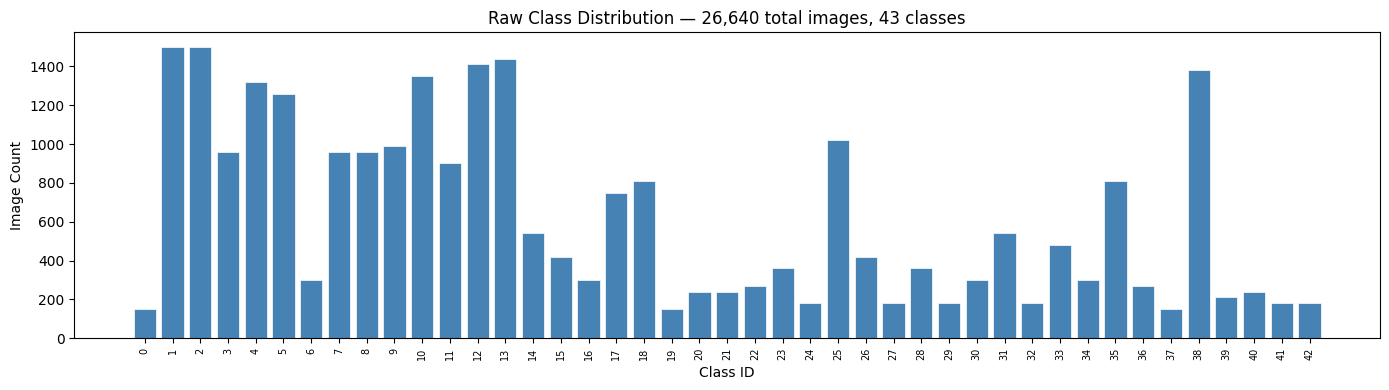

Min images in a class : 150
Max images in a class : 1500
Mean per class        : 620


In [7]:
raw_counts = {}
for _, label in train_dataset:
    raw_counts[label] = raw_counts.get(label, 0) + 1

classes = sorted(raw_counts.keys())
counts  = [raw_counts[c] for c in classes]

plt.figure(figsize=(14, 4))
plt.bar(classes, counts, color="steelblue", edgecolor="white", linewidth=0.5)
plt.xlabel("Class ID")
plt.ylabel("Image Count")
plt.title(f"Raw Class Distribution — {len(train_dataset):,} total images, {len(classes)} classes")
plt.xticks(classes, rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print(f"Min images in a class : {min(counts)}")
print(f"Max images in a class : {max(counts)}")
print(f"Mean per class        : {sum(counts)/len(counts):.0f}")


In [8]:
def sample_per_class(dataset, max_per_class, seed=42):
    random.seed(seed)
    buckets = {}
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        buckets.setdefault(label, []).append(idx)

    sampled = []
    for label, indices in sorted(buckets.items()):
        chosen = random.sample(indices, min(max_per_class, len(indices)))
        sampled.extend(chosen)

    return sampled

print(f"Sampling up to {MAX_PER_CLASS} images per class...")
sampled_indices = sample_per_class(train_dataset, MAX_PER_CLASS, seed=SEED)
print(f"Total sampled: {len(sampled_indices):,} images")


Sampling up to 200 images per class...
Total sampled: 8,330 images


In [ ]:
def clean_image(pil_img, img_size):
    img = pil_img.convert("RGB")
    min_dim = min(img.size)
    if min_dim < 20:
        return None                                      
    img = ImageOps.fit(img, (min_dim, min_dim), method=Image.LANCZOS)  # Square crop
    img = img.resize((img_size, img_size), Image.LANCZOS)              # Resize
    return img

def build_processed_dataset(dataset, indices, output_dir, img_size):
    img_dir = Path(output_dir) / "images"
    img_dir.mkdir(parents=True, exist_ok=True)
    manifest_path = Path(output_dir) / "manifest.csv"

    rejected = 0
    saved = 0

    with open(manifest_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["filename", "class_id"])

        for idx in indices:
            pil_img, label = dataset[idx]
            cleaned = clean_image(pil_img, img_size)
            if cleaned is None:
                rejected += 1
                continue
            filename = f"{saved:06d}_class{label:02d}.png"
            cleaned.save(img_dir / filename)
            writer.writerow([filename, label])
            saved += 1

    print(f"Saved   : {saved:,} images → {img_dir}")
    print(f"Rejected: {rejected} images (too small)")
    print(f"Manifest: {manifest_path}")
    return manifest_path

print("Cleaning and saving images...")
manifest_path = build_processed_dataset(
    train_dataset, sampled_indices, PROCESSED_DIR, IMG_SIZE
)


Cleaning and saving images...
Saved   : 8,330 images → data/processed/images
Rejected: 0 images (too small)
Manifest: data/processed/manifest.csv


In [10]:
class RoadSignDataset(Dataset):
    def __init__(self, processed_dir, img_size):
        self.img_dir  = Path(processed_dir) / "images"
        self.manifest = []

        with open(Path(processed_dir) / "manifest.csv") as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.manifest.append((row["filename"], int(row["class_id"])))

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ColorJitter(            # Mild augmentation for lighting variation
                brightness=0.1,
                contrast=0.1,
                saturation=0.1,
                hue=0.02,
            ),
            transforms.ToTensor(),             # [0, 1]
            transforms.Normalize(              # → [-1, 1]
                mean=[0.5, 0.5, 0.5],
                std =[0.5, 0.5, 0.5],
            ),
        ])

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        filename, class_id = self.manifest[idx]
        img = Image.open(self.img_dir / filename).convert("RGB")
        return self.transform(img), class_id

road_sign_dataset = RoadSignDataset(PROCESSED_DIR, IMG_SIZE)
print(f"Dataset size: {len(road_sign_dataset):,} images")


Dataset size: 8,330 images


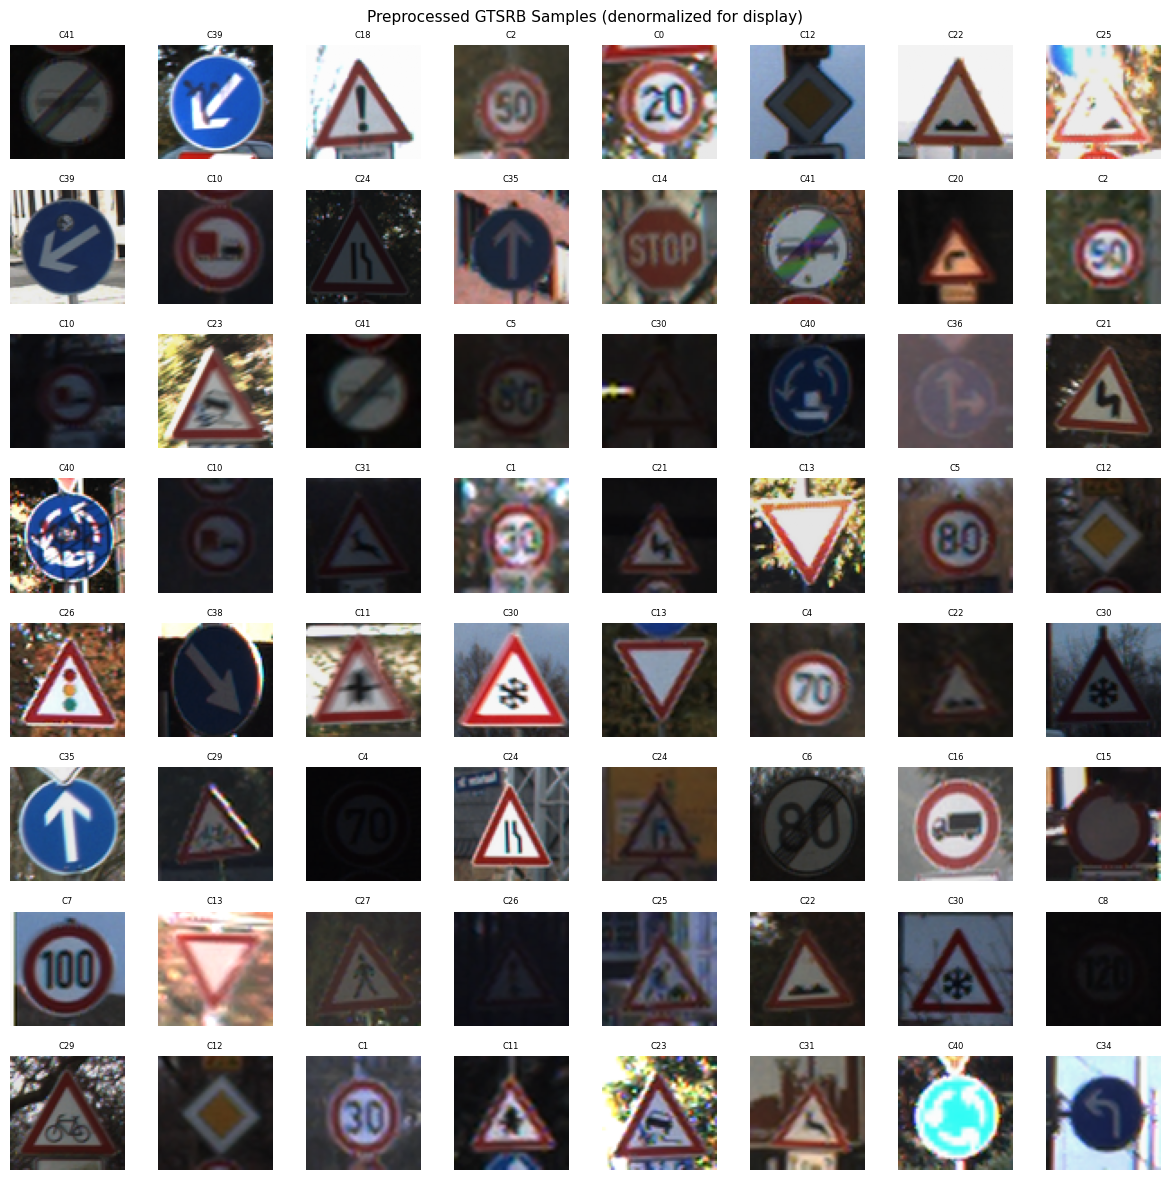

Sample grid saved.


In [11]:
def plot_sample_grid(dataset, n=64):
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    cols = 8
    rows = (len(indices) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        tensor, class_id = dataset[idx]
        img_np = (tensor.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
        axes[i].imshow(img_np)
        axes[i].set_title(f"C{class_id}", fontsize=6)
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Preprocessed GTSRB Samples (denormalized for display)", fontsize=11)
    plt.tight_layout()
    plt.savefig(Path(PROCESSED_DIR) / "sample_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Sample grid saved.")

plot_sample_grid(road_sign_dataset, n=64)
